In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('gold.csv')
df.head()

,Date,Open,High,Low,Close,Volume,Currency
0,2000-01-04,289.5,289.5,280.0,283.7,21621,USD
1,2000-01-05,283.7,285.0,281.0,282.1,25448,USD
2,2000-01-06,281.6,282.8,280.2,282.4,19055,USD
3,2000-01-07,282.5,284.5,282.0,282.9,11266,USD
4,2000-01-10,282.4,283.9,281.8,282.7,30603,USD


EDA

In [3]:
df.shape

(5703, 7)

In [4]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Currency'], dtype='object')

In [5]:
df.info() # Information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5703 entries, 0 to 5702
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      5703 non-null   object 
 1   Open      5703 non-null   float64
 2   High      5703 non-null   float64
 3   Low       5703 non-null   float64
 4   Close     5703 non-null   float64
 5   Volume    5703 non-null   int64  
 6   Currency  5703 non-null   object 
dtypes: float64(4), int64(1), object(2)
memory usage: 312.0+ KB


In [6]:
df.describe() #Statistical Summary

,Open,High,Low,Close,Volume
count,5703.000000,5703.000000,5703.000000,5703.000000,5703.000000
mean,1040.382816,1048.339181,1031.863169,1040.298282,139141.669297
std,518.733377,522.353946,514.455903,518.524020,102537.449058
min,256.600000,259.400000,255.100000,256.600000,0.000000
25%,459.850000,463.900000,457.450000,460.500000,52938.500000
50%,1188.800000,1198.000000,1179.700000,1188.700000,126006.000000
75%,1381.400000,1392.750000,1368.100000,1383.050000,193109.000000
max,2076.400000,2089.200000,2049.000000,2069.400000,816531.000000


In [7]:
df.isnull().sum() # Missing Values

Date        0
Open        0
High        0
Low         0
Close       0
Volume      0
Currency    0
dtype: int64

In [8]:
df.dtypes # Data Types

Date         object
Open        float64
High        float64
Low         float64
Close       float64
Volume        int64
Currency     object
dtype: object

In [16]:
df['Date'] = pd.to_datetime(df['Date'])
df.head()

,Date,Open,High,Low,Close,Volume,Currency,Price_Change,Volatility
0,2000-01-04,289.5,289.5,280.0,283.7,21621,USD,-5.8,9.5
1,2000-01-05,283.7,285.0,281.0,282.1,25448,USD,-1.6,4.0
2,2000-01-06,281.6,282.8,280.2,282.4,19055,USD,0.8,2.6
3,2000-01-07,282.5,284.5,282.0,282.9,11266,USD,0.4,2.5
4,2000-01-10,282.4,283.9,281.8,282.7,30603,USD,0.3,2.1


In [13]:
print("Start Date:", df['Date'].min())
print("End Date:", df['Date'].max())

Start Date: 2000-01-04 00:00:00
End Date: 2022-09-02 00:00:00


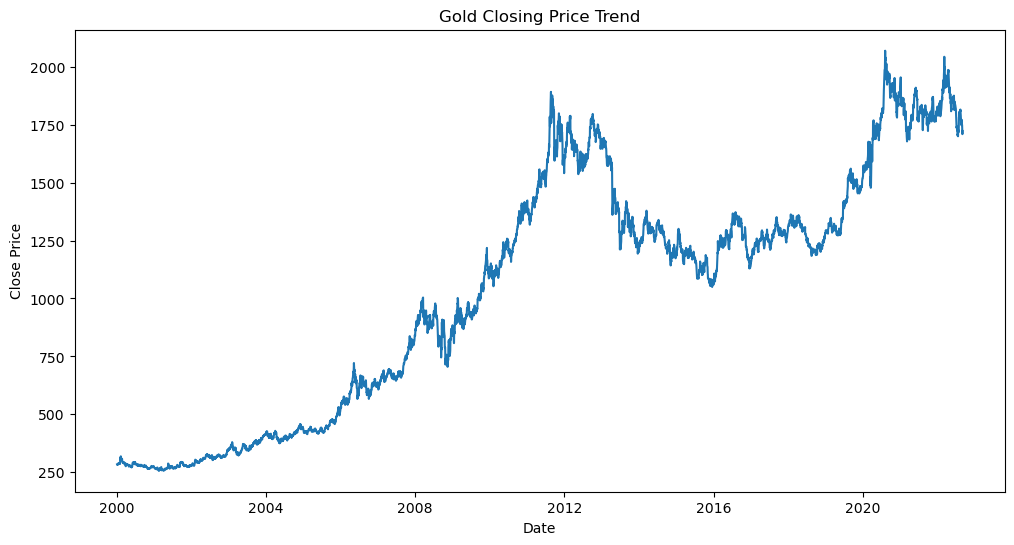

In [14]:
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Close'])
plt.title('Gold Closing Price Trend')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.show()

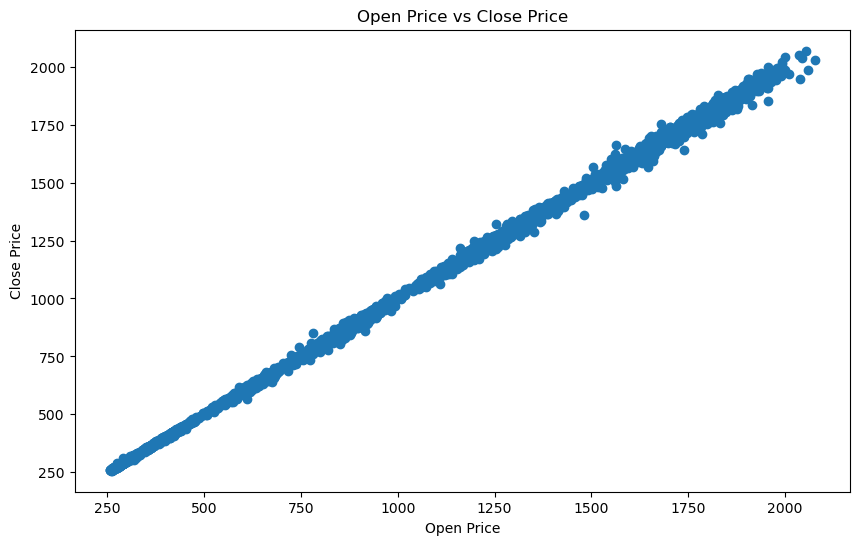

In [15]:
plt.figure(figsize=(10,6))
plt.scatter(df['Open'], df['Close'])
plt.title('Open Price vs Close Price')
plt.xlabel('Open Price')
plt.ylabel('Close Price')
plt.show()

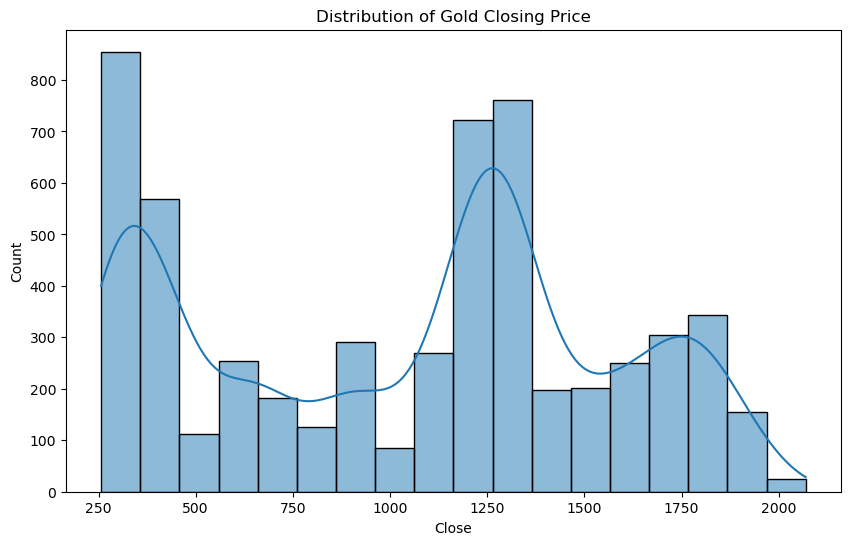

In [16]:
plt.figure(figsize=(10,6))
sns.histplot(df['Close'], kde=True)
plt.title('Distribution of Gold Closing Price')
plt.show()

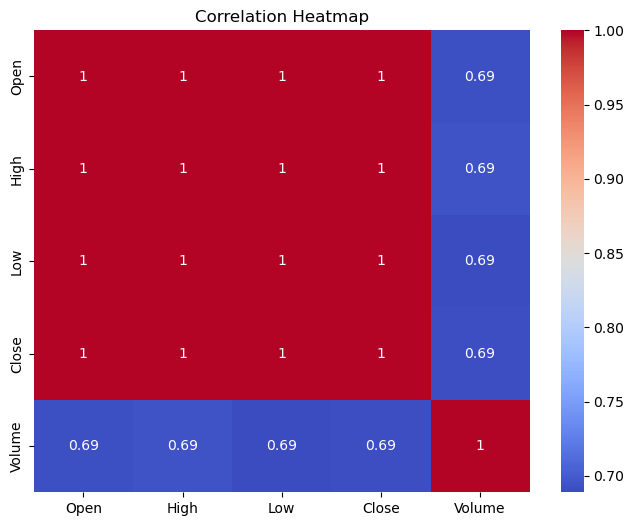

In [17]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['Open','High','Low','Close','Volume']].corr(),
            annot=True,
            cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

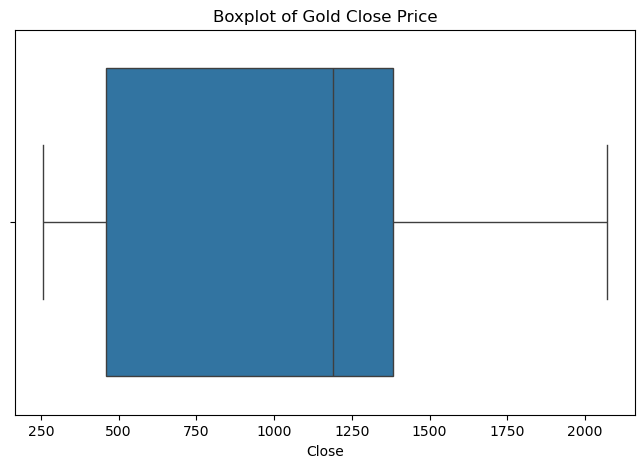

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Close'])
plt.title('Boxplot of Gold Close Price')
plt.show()

Volatility Analytics

Daily Price Change

In [4]:
df['Price_Change'] = df['Close'] - df['Open']

df[['Date','Open','Close','Price_Change']].head()

,Date,Open,Close,Price_Change
0,2000-01-04,289.5,283.7,-5.8
1,2000-01-05,283.7,282.1,-1.6
2,2000-01-06,281.6,282.4,0.8
3,2000-01-07,282.5,282.9,0.4
4,2000-01-10,282.4,282.7,0.3


Daily Volatility

In [5]:
df['Volatility'] = df['High'] - df['Low']

df[['Date','High','Low','Volatility']].head()

,Date,High,Low,Volatility
0,2000-01-04,289.5,280.0,9.5
1,2000-01-05,285.0,281.0,4.0
2,2000-01-06,282.8,280.2,2.6
3,2000-01-07,284.5,282.0,2.5
4,2000-01-10,283.9,281.8,2.1


Volatility Trend

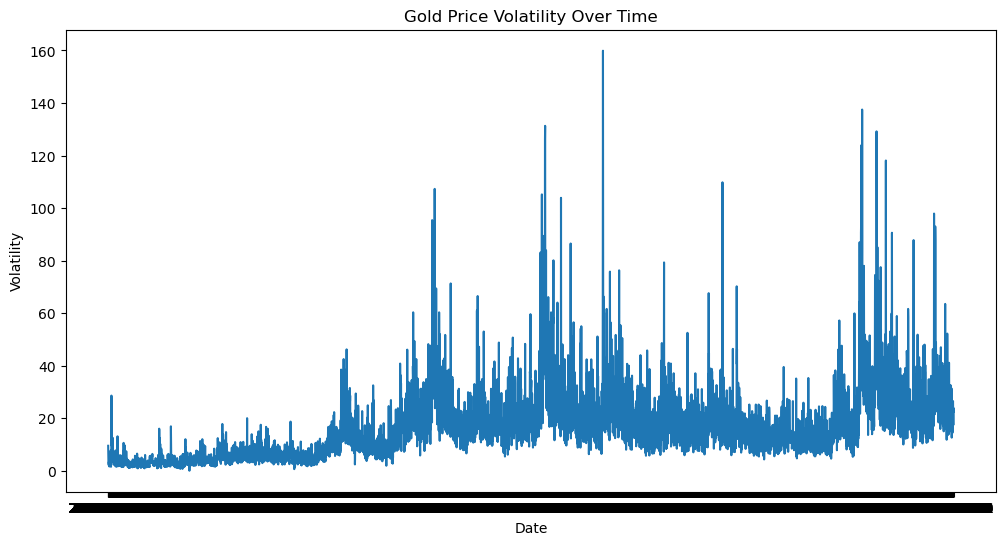

In [10]:
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Volatility'])
plt.title('Gold Price Volatility Over Time')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.show()

The volatility generally shows an increasing trend over time.
This suggests that gold price fluctuations became larger during later years compared to earlier years.

Top 10 Most Volatile Days

In [11]:
df.nlargest(10, 'Volatility')[['Date','Volatility']]

,Date,Volatility
3337,2013-04-15,159.9
5085,2020-03-24,137.5
2947,2011-09-26,131.3
5182,2020-08-11,129.2
2946,2011-09-23,126.2
5079,2020-03-16,123.9
5245,2020-11-09,118.1
4143,2016-06-24,109.8
2202,2008-10-10,107.3
2925,2011-08-24,105.2


The highest volatility was observed on 2013-04-15.
The volatility value reached 159.9, indicating a major price fluctuation on that day.

Average Volatility

In [12]:
df['Volatility'].mean()

np.float64(16.47601262493425)

The average gold price volatility was 16.48.
This indicates that, on average, the difference between daily high and low prices was around 16.48 units.

Feature Engineering

In [17]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

df[['Date','Year','Month','Day']].head()

,Date,Year,Month,Day
0,2000-01-04,2000,1,4
1,2000-01-05,2000,1,5
2,2000-01-06,2000,1,6
3,2000-01-07,2000,1,7
4,2000-01-10,2000,1,10


In [18]:
df.head()

,Date,Open,High,Low,Close,Volume,Currency,Price_Change,Volatility,Year,Month,Day
0,2000-01-04,289.5,289.5,280.0,283.7,21621,USD,-5.8,9.5,2000,1,4
1,2000-01-05,283.7,285.0,281.0,282.1,25448,USD,-1.6,4.0,2000,1,5
2,2000-01-06,281.6,282.8,280.2,282.4,19055,USD,0.8,2.6,2000,1,6
3,2000-01-07,282.5,284.5,282.0,282.9,11266,USD,0.4,2.5,2000,1,7
4,2000-01-10,282.4,283.9,281.8,282.7,30603,USD,0.3,2.1,2000,1,10


In [19]:
X = df[['Open', 'High', 'Low', 'Volume', 'Year', 'Month', 'Day']]
y = df['Close']

In [20]:
print(X.shape)
print(y.shape)

(5703, 7)
(5703,)


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2 , random_state = 42)
print(X_train.shape)
print(X_test.shape)

(4562, 7)
(1141, 7)


In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [23]:
lr = LinearRegression()

lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Linear Regression model was trained on the gold price dataset.

In [24]:
y_pred = lr.predict(X_test)

In [25]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 2.9824836159369084
MSE : 21.964121437183785
RMSE : 4.686589531544637
R2 Score : 0.9999219031380453


The Linear Regression model performed exceptionally well on the Gold Price dataset. The model achieved an R² Score of 0.99992, indicating that it explained more than 99.99% of the variance in gold prices. The low MAE (2.98) and RMSE (4.69) values suggest highly accurate predictions.

Actual vs Predicted

In [26]:
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

results.head(10)

,Actual,Predicted
1436,469.3,470.523476
748,351.6,350.043787
3463,1268.2,1272.321312
1448,463.2,463.993748
4351,1277.5,1269.175158
944,376.2,374.741193
1595,637.5,645.740983
1666,646.9,644.622660
4043,1127.2,1126.873883
4444,1344.5,1340.153835


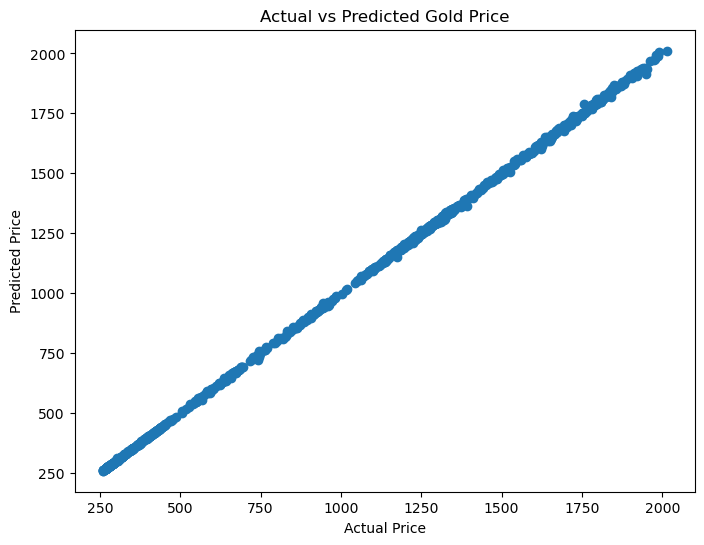

In [27]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Gold Price")
plt.show()

The scatter plot shows the relationship between actual and predicted prices.

# Multiple Algorithm Comparison using GridSearchCV

Hyperparameter tuning

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
import pandas as pd

In [29]:
model_params = {

    'linear_regression': {
        'model': LinearRegression(),
        'params': {}
    },

    'decision_tree': {
        'model': DecisionTreeRegressor(random_state=42),
        'params': {
            'max_depth': [5, 10, 15],
            'min_samples_split': [2, 5, 10]
        }
    },

    'random_forest': {
        'model': RandomForestRegressor(random_state=42),
        'params': {
            'n_estimators': [50, 100],
            'max_depth': [5, 10]
        }
    },

    'gradient_boosting': {
        'model': GradientBoostingRegressor(random_state=42),
        'params': {
            'n_estimators': [50, 100],
            'learning_rate': [0.01, 0.1]
        }
    }
}

In [30]:
scores = []

for model_name, mp in model_params.items():

    clf = GridSearchCV(
        mp['model'],
        mp['params'],
        cv=3,
        scoring='r2'
    )

    clf.fit(X_train, y_train)

    scores.append({
        'model': model_name,
        'best_score': clf.best_score_,
        'best_params': clf.best_params_
    })

In [31]:
df_scores = pd.DataFrame(scores)

df_scores

,model,best_score,best_params
0,linear_regression,0.999918,{}
1,decision_tree,0.999727,"{'max_depth': 10, 'min_samples_split': 10}"
2,random_forest,0.999837,"{'max_depth': 10, 'n_estimators': 100}"
3,gradient_boosting,0.999775,"{'learning_rate': 0.1, 'n_estimators': 100}"


In [32]:
df_scores.sort_values(
    by='best_score',
    ascending=False
)

,model,best_score,best_params
0,linear_regression,0.999918,{}
2,random_forest,0.999837,"{'max_depth': 10, 'n_estimators': 100}"
3,gradient_boosting,0.999775,"{'learning_rate': 0.1, 'n_estimators': 100}"
1,decision_tree,0.999727,"{'max_depth': 10, 'min_samples_split': 10}"


Four regression algorithms were evaluated using GridSearchCV and 3-fold cross-validation. Linear Regression achieved the highest R² score of 0.999918, outperforming Random Forest, Gradient Boosting, and Decision Tree Regressor. Therefore, Linear Regression was selected as the final forecasting model for gold price prediction.

Final Model Selection

In [36]:
from sklearn.linear_model import LinearRegression

final_model = LinearRegression()
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

Final Evaluation

In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score :", r2_score(y_test, y_pred))

MAE : 2.9824836159369084
MSE : 21.964121437183785
RMSE : 4.686589531544637
R2 Score : 0.9999219031380453


Save the Model

In [38]:
import joblib

joblib.dump(final_model, 'gold_price_forecasting_model.pkl')

print("Model saved successfully!")

Model saved successfully!


## Conclusion

This project successfully developed a Global Supply Chain Commodity Price Forecasting and Volatility Analytics System using Machine Learning techniques. Exploratory Data Analysis (EDA), volatility analysis, feature engineering, model comparison, and hyperparameter tuning were performed to improve forecasting performance. Multiple regression algorithms, including Linear Regression, Decision Tree, Random Forest, and Gradient Boosting, were evaluated using GridSearchCV. Among all models, Linear Regression achieved the highest R² score and was selected as the final model. The trained model was saved and deployed using Streamlit for real-time commodity price prediction.
